# Plan-and-Execute

This notebook shows how to create a "plan-and-execute" style agent. This is heavily inspired by the [Plan-and-Solve](https://arxiv.org/abs/2305.04091) paper as well as the [Baby-AGI](https://github.com/yoheinakajima/babyagi) project.

The core idea is to first come up with a multi-step plan, and then go through that plan one item at a time.
After accomplishing a particular task, you can then revisit the plan and modify as appropriate.


This compares to a typical [ReAct](https://arxiv.org/abs/2210.03629) style agent where you think one step at a time.
The advantages of this "plan-and-execute" style agent are:

1. Explicit long term planning (which even really strong LLMs can struggle with)
2. Ability to use smaller/weaker models for the execution step, only using larger/better models for the planning step

## Setup

First, we need to install the packages required.

In [5]:
#%%capture --no-stderr
%pip install --quiet -U langgraph langchain langchain-community langchain-openai tavily-python langchain-core langchain-mcp-adapters 


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Next, we need to set API keys for OpenAI (the LLM we will use) and Tavily (the search tool we will use)

<div class="admonition tip">
    <p class="admonition-title">Set up <a href="https://smith.langchain.com">LangSmith</a> for LangGraph development</p>
    <p style="padding-top: 5px;">
        Sign up for LangSmith to quickly spot issues and improve the performance of your LangGraph projects. LangSmith lets you use trace data to debug, test, and monitor your LLM apps built with LangGraph — read more about how to get started <a href="https://docs.smith.langchain.com">here</a>. 
    </p>
</div>

## Define Tools

We will first define the tools we want to use. For this simple example, we will use a built-in search tool via Tavily. However, it is really easy to create your own tools - see documentation [here](https://python.langchain.com/docs/how_to/custom_tools) on how to do that.

In [1]:
import langchain
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_mcp_adapters.client import MultiServerMCPClient
langchain.debug = True


# MCP Client via HTTP
client = MultiServerMCPClient(
    {
        "mlops_tai_engineers": {
            "transport": "streamable_http",
            "url": "http://127.0.0.1:8081/mcp"  
        },
        "file_system": {
            "transport": "streamable_http",
            "url": "http://127.0.0.1:8080/mcp"  
        }
    }
)
structured_tools = await client.get_tools()
tools = structured_tools + [TavilySearchResults(max_results=3)]

/tmp/ipykernel_46929/2898034990.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


ImportError: cannot import name 'streamable_http_client' from 'mcp.client.streamable_http' (/home/albana/.pyenv/versions/3.12.1/lib/python3.12/site-packages/mcp/client/streamable_http.py)

## Define our Execution Agent

Now we will create the execution agent we want to use to execute tasks. 
Note that for this example, we will be using the same execution agent for each task, but this doesn't HAVE to be the case.

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

#claude
#sonnet
#gpt 5
# Choose the LLM that will drive the agent
llm = ChatOpenAI(
    model="gpt-4-turbo-preview",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
)
prompt = "You are a helpful assistant."
agent_executor = create_agent(llm, tools, system_prompt=prompt)

In [2]:
!ls prompts

1.planner_prompt_data_profiling.txt  claude_sys_prompt.md  user_prompt_qa.txt
2.system_prompt_codegen.txt	     deployer_prompts
3.user_prompt_codegen.txt	     system_prompt_qa.txt


In [ ]:
SYSTEM_PROMPT ="
USER_PROMPT = "Which is the list of operations for data preparation stage in the lifecycle of an AI product? Write each operation in separated files located at my Desktop."

In [100]:
res = await agent_executor.ainvoke({"messages": [("user", USER_PROMPT)]})
res

{'messages': [HumanMessage(content='Which is the list of operations for data preparation stage in the lifecycle of an AI product? Write each operation in separated files located at my Desktop.', additional_kwargs={}, response_metadata={}, id='39dd7da4-a31b-42ed-9078-6cbfb1765051'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 1301, 'total_tokens': 1313, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4-0125-preview', 'system_fingerprint': None, 'id': 'chatcmpl-DDM6XjR4wCzPau6SWe71ngAmPiKyi', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c97ef-dcd5-76d0-8ab2-7901af5cf828-0', tool_calls=[{'name': 'list_user_directories', 'args': {}, 'id': 'call_5yi7n

### Dynamic Model

Dynamic models are selected at runtime based on the current state and context. This enables sophisticated routing logic and cost optimization.

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse


basic_model = ChatOpenAI(model="gpt-4.1-mini")
advanced_model = ChatOpenAI(model="gpt-4.1")

@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    """Choose model based on conversation complexity."""
    message_count = len(request.state["messages"])

    if message_count > 10:
        # Use an advanced model for longer conversations
        model = advanced_model
    else:
        model = basic_model

    return handler(request.override(model=model))

agent = create_agent(
    model=basic_model,  # Default model
    tools=tools,
    middleware=[dynamic_model_selection]
)

## Define the State

Let's now start by defining the state the track for this agent.

First, we will need to track the current plan. Let's represent that as a list of strings.

Next, we should track previously executed steps. Let's represent that as a list of tuples (these tuples will contain the step and then the result)

Finally, we need to have some state to represent the final response as well as the original input.

In [90]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


class PlanExecute(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    response: str

## Planning Step

Let's now think about creating the planning step. This will use function calling to create a plan.

<div class="admonition note">
    <p class="admonition-title">Using Pydantic with LangChain</p>
    <p>
        This notebook uses Pydantic v2 <code>BaseModel</code>, which requires <code>langchain-core >= 0.3</code>. Using <code>langchain-core < 0.3</code> will result in errors due to mixing of Pydantic v1 and v2 <code>BaseModels</code>.
    </p>
</div>

In [91]:
from pydantic import BaseModel, Field


class Plan(BaseModel):
    """Plan to follow in future"""

    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order"
    )

In [92]:
from langchain_core.prompts import ChatPromptTemplate

planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.""",
        ),
        ("placeholder", "{messages}"),
    ]
)
planner = planner_prompt | ChatOpenAI(
    model="gpt-4o", temperature=0
).with_structured_output(Plan)

In [93]:
planner.invoke(
    {
        "messages": [
            #("user", "Which are the operations for data preparation stage in the lifecycle of an AI product?")
            ("user", "Which are the operations for data preparation stage in the lifecycle of an AI product?")
        ]
    }
)

/home/albana/.pyenv/versions/3.12.1/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(steps=['Identify the... and reproducibility.']), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


Plan(steps=['Identify the data sources relevant to the AI product.', 'Collect the data from identified sources.', 'Perform data cleaning to remove or correct any errors or inconsistencies in the data.', 'Conduct data transformation to convert data into a suitable format or structure for analysis.', 'Perform data integration to combine data from different sources into a unified dataset.', 'Conduct data reduction to reduce the volume of data while maintaining its integrity.', 'Perform data normalization to scale the data to a standard range or distribution.', 'Conduct data enrichment to enhance the dataset with additional information or context.', 'Perform data validation to ensure the data is accurate, complete, and reliable.', 'Document the data preparation process for future reference and reproducibility.'])

## Re-Plan Step

Now, let's create a step that re-does the plan based on the result of the previous step.

In [94]:
from typing import Union


class Response(BaseModel):
    """Response to user."""

    response: str


class Act(BaseModel):
    """Action to perform."""

    action: Union[Response, Plan] = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )


replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

Your objective was this:
{input}

Your original plan was this:
{plan}

You have currently done the follow steps:
{past_steps}

Update your plan accordingly. If no more steps are needed and you can return to the user, then respond with that. Otherwise, fill out the plan. Only add steps to the plan that still NEED to be done. Do not return previously done steps as part of the plan."""
)


replanner = replanner_prompt | ChatOpenAI(
    model="gpt-4o", temperature=0
).with_structured_output(Act)

## Create the Graph

We can now create the graph!

In [95]:
from typing import Literal
from langgraph.graph import END
from langgraph.prebuilt import ToolNode


async def execute_step(state: PlanExecute):
    plan = state["plan"]
    plan_str = "\n".join(f"{i + 1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    task_formatted = f"""For the following plan:
{plan_str}\n\nYou are tasked with executing step {1}, {task}."""
    agent_response = await agent_executor.ainvoke(
        {"messages": [("user", task_formatted)]}
    )
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


async def plan_step(state: PlanExecute):
    plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    return {"plan": plan.steps}


async def replan_step(state: PlanExecute):
    output = await replanner.ainvoke(state)
    if isinstance(output.action, Response):
        return {"response": output.action.response}
    else:
        return {"plan": output.action.steps}


def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return END
    else:
        return "agent"

In [96]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(PlanExecute)

# Add the plan node
workflow.add_node("planner", plan_step)

# Add the execution step
workflow.add_node("agent", execute_step)

# Add a replan node
workflow.add_node("replan", replan_step)


workflow.add_edge(START, "planner")

# From plan we go to agent
workflow.add_edge("planner", "agent")

# From agent, we replan
workflow.add_edge("agent", "replan")


workflow.add_conditional_edges(
    "replan",
    # Next, we pass in the function that will determine which node is called next.
    should_end,
    ["agent", END],
)

# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable
app = workflow.compile()

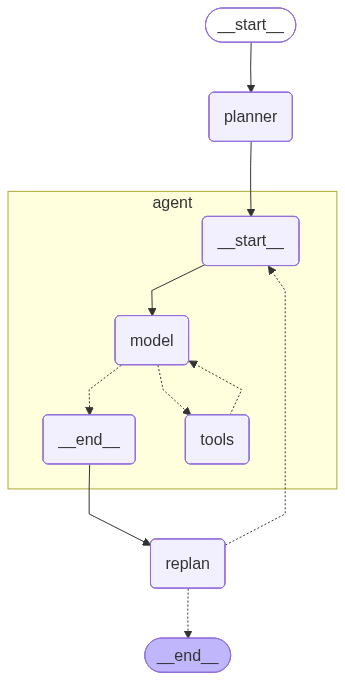

In [97]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [101]:
config = {"recursion_limit": 50}
inputs = {"input": USER_PROMPT}
async for event in app.astream(inputs, config=config):
    for k, v in event.items():
        if k != "__end__":
            print(v)

/home/albana/.pyenv/versions/3.12.1/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(steps=["Create a new...lder on your Desktop."]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


{'plan': ["Create a new folder on your Desktop named 'Data Preparation Operations'.", 'Open a text editor application on your computer.', "In the text editor, write the first operation for data preparation: 'Data Collection'.", "Save this file as '1_Data_Collection.txt' in the 'Data Preparation Operations' folder on your Desktop.", "In the text editor, write the second operation for data preparation: 'Data Cleaning'.", "Save this file as '2_Data_Cleaning.txt' in the 'Data Preparation Operations' folder on your Desktop.", "In the text editor, write the third operation for data preparation: 'Data Integration'.", "Save this file as '3_Data_Integration.txt' in the 'Data Preparation Operations' folder on your Desktop.", "In the text editor, write the fourth operation for data preparation: 'Data Transformation'.", "Save this file as '4_Data_Transformation.txt' in the 'Data Preparation Operations' folder on your Desktop.", "In the text editor, write the fifth operation for data preparation: '

/home/albana/.pyenv/versions/3.12.1/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Act(action=Plan(steps=['O...der on your Desktop."])), input_type=Act])
  return self.__pydantic_serializer__.to_python(


{'plan': ['Open a text editor application on your computer.', "In the text editor, write the first operation for data preparation: 'Data Collection'.", "Save this file as '1_Data_Collection.txt' in the 'Data Preparation Operations' folder on your Desktop.", "In the text editor, write the second operation for data preparation: 'Data Cleaning'.", "Save this file as '2_Data_Cleaning.txt' in the 'Data Preparation Operations' folder on your Desktop.", "In the text editor, write the third operation for data preparation: 'Data Integration'.", "Save this file as '3_Data_Integration.txt' in the 'Data Preparation Operations' folder on your Desktop.", "In the text editor, write the fourth operation for data preparation: 'Data Transformation'.", "Save this file as '4_Data_Transformation.txt' in the 'Data Preparation Operations' folder on your Desktop.", "In the text editor, write the fifth operation for data preparation: 'Data Reduction'.", "Save this file as '5_Data_Reduction.txt' in the 'Data Pr

/home/albana/.pyenv/versions/3.12.1/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Act(action=Plan(steps=["I...der on your Desktop."])), input_type=Act])
  return self.__pydantic_serializer__.to_python(


...

/home/albana/.pyenv/versions/3.12.1/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Act(action=Plan(steps=["I...der on your Desktop."])), input_type=Act])
  return self.__pydantic_serializer__.to_python(


{'plan': ["In the text editor, write the sixth operation for data preparation: 'Data Discretization'.", "Save the file with the content for 'Data Discretization' as '6_Data_Discretization.txt' in the 'Data Preparation Operations' folder on your Desktop."]}
{'past_steps': [("In the text editor, write the sixth operation for data preparation: 'Data Discretization'.", "Data Discretization is a crucial step in data preparation, especially when dealing with continuous data that needs to be used in machine learning models that handle categorical data better. This process involves converting a range of continuous data values into a finite set of discrete intervals, often called bins. The main goal of data discretization is to simplify the data and reduce the complexity of its distribution without significantly losing information.\n\n### Key Points of Data Discretization:\n\n- **Simplification**: It simplifies the data and makes it easier to analyze and visualize by grouping continuous data po

/home/albana/.pyenv/versions/3.12.1/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Act(action=Plan(steps=["S...der on your Desktop."])), input_type=Act])
  return self.__pydantic_serializer__.to_python(


{'plan': ["Save the file with the content for 'Data Discretization' as '6_Data_Discretization.txt' in the 'Data Preparation Operations' folder on your Desktop."]}
{'past_steps': [("Save the file with the content for 'Data Discretization' as '6_Data_Discretization.txt' in the 'Data Preparation Operations' folder on your Desktop.", 'The file `6_Data_Discretization.txt` has been successfully saved in the `Data Preparation Operations` folder on your Desktop.')]}
{'response': "All the necessary steps for saving the operations for the data preparation stage in separate files on your Desktop have been completed. You have successfully created and saved the following files in the 'Data Preparation Operations' folder:\n\n1. `1_Data_Collection.txt`\n2. `2_Data_Cleaning.txt`\n3. `3_Data_Integration.txt`\n4. `4_Data_Transformation.txt`\n5. `5_Data_Reduction.txt`\n6. `6_Data_Discretization.txt`\n\nNo further steps are needed. If you have any more tasks or need further assistance, feel free to ask!"}

/home/albana/.pyenv/versions/3.12.1/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Act(action=Response(respo...ce, feel free to ask!")), input_type=Act])
  return self.__pydantic_serializer__.to_python(


## Conclusion

One known limitations of the above design is that each task is still executed in sequence, meaning embarrassingly parallel operations all add to the total execution time. We could improve on this by having each task represented as a DAG (similar to LLMCompiler), rather than a regular list.

# References

- https://github.com/ashishpatel26/500-AI-Agents-Projects?tab=readme-ov-file#framework-name-crewai   
- https://github.com/langchain-ai/langgraph/blob/23961cff61a42b52525f3b20b4094d8d2fba1744/docs/docs/tutorials/plan-and-execute/plan-and-execute.ipynb
- https://github.com/langchain-ai/langgraph/blob/23961cff61a42b52525f3b20b4094d8d2fba1744/docs/docs/tutorials/code_assistant/langgraph_code_assistant.ipynb